# Track 6 — AI-Powered Analysis & Reporting: Exploratory Data Analysis

This notebook explores the STR (Suspicious Transaction Report) dataset to understand narrative quality,
entity distribution, summarisation challenges, and key patterns relevant to building an AI summarisation system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv("data/track6_reports_with_entities.csv")
df.shape

(276, 30)

## 1. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("Column Names and Data Types:")
print("="*50)
print(df.dtypes)
print("\n" + "="*50)
print("First few rows:")
print("="*50)
df.head()

Dataset Shape: (276, 30)

Column Names and Data Types:
source_file                     object
report_id                       object
entity_reference                object
submission_date                 object
currency_code                   object
narrative                       object
narrative_length                 int64
report_type                     object
transaction_number              object
amount_local                   float64
date_transaction                object
transaction_location            object
transaction_mode_code           object
transaction_mode                object
from_institution                object
from_account_name               object
from_account_number             object
from_country                    object
to_institution                  object
to_account_name                 object
to_account_number               object
to_country                      object
entities_json                   object
entities_customer_names         object
entities_

,source_file,report_id,entity_reference,submission_date,currency_code,narrative,narrative_length,report_type,transaction_number,amount_local,...,to_account_number,to_country,entities_json,entities_customer_names,entities_counterparty_names,entities_bank_names,entities_amounts,entities_dates,entities_transaction_modes,entities_countries
0,report_000001.xml,RPT-2026-000001,NIMB-2026-000001,2026-06-14T15:42:08,NPR,Suspicious transaction observed.,32,Type-A,SAMLD-7401327478-317,535368.64,...,NP00000000003980427782,GB,"{""account_numbers"": [""NP00000000003412850188"",...",John Jensen,Jeremy Martinez,PCBL; SBL,NPR 535368.64,2022-10-07,Cash Deposit transfer,GB
1,report_000002.xml,RPT-2026-000002,SBL-2026-000002,2026-06-14T15:42:08,NPR,During the branch's periodic transaction-monit...,1264,Type-B,SAMLD-6340007440-1206,21807.13,...,NP00000000000894070684,IN,"{""account_numbers"": [""NP00000000000983174071"",...",Sally Dominguez,Henry King,ADBL; HBL,NPR 21807.13,2022-10-07,Cash Withdrawal transfer,GB; IN
2,report_000003.xml,RPT-2026-000003,RBBL-2026-000003,2026-06-14T15:42:08,NPR,During the branch's periodic transaction-monit...,1283,Type-B,SAMLD-3758118046-1649,1214019.81,...,NP00000000000310823462,MX,"{""account_numbers"": [""NP00000000002968635055"",...","Cook, Flores and Ray",Chad Mccarty,KUMARI; SBL,NPR 1214019.81,2022-10-07,Cross-border transfer,GB; MX
3,report_000004.xml,RPT-2026-000004,HBL-2026-000004,2026-06-14T15:42:08,NPR,During the branch's periodic transaction-monit...,1264,Type-B,SAMLD-445154846-1954,813935.97,...,NP00000000004011650754,NG,"{""account_numbers"": [""NP00000000001187666276"",...",Robert King,Sarah English,PRABHU; LAXMI,NPR 813935.97,2022-10-07,Cross-border transfer,GB; NG
4,report_000005.xml,RPT-2026-000005,MBL-2026-000005,2026-06-14T15:42:08,NPR,Suspicious transaction observed.,32,Type-A,SAMLD-2758469152-3304,1610735.12,...,NP00000000003038338293,GB,"{""account_numbers"": [""NP00000000003628175933"",...",Porter LLC,Terrence Davis,MEGA,NPR 1610735.12,2022-10-07,Debit card transfer,GB


In [4]:
print("Missing Values:")
print("="*50)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

Missing Values:
No missing values found!


In [5]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Total duplicate rows: 0


## 2. Narrative Length & Report Type Analysis

Key question: How do narratives differ between Type-A (minimal) and Type-B (detailed) reports?

Report Type Distribution:
report_type
Type-B    176
Type-A    100
Name: count, dtype: int64

Percentage Type-A: 36.2%
Percentage Type-B: 63.8%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20740\1817270403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='report_type', y='narrative_length', ax=axes[2], palette={'Type-A': '#e74c3c', 'Type-B': '#3498db'})


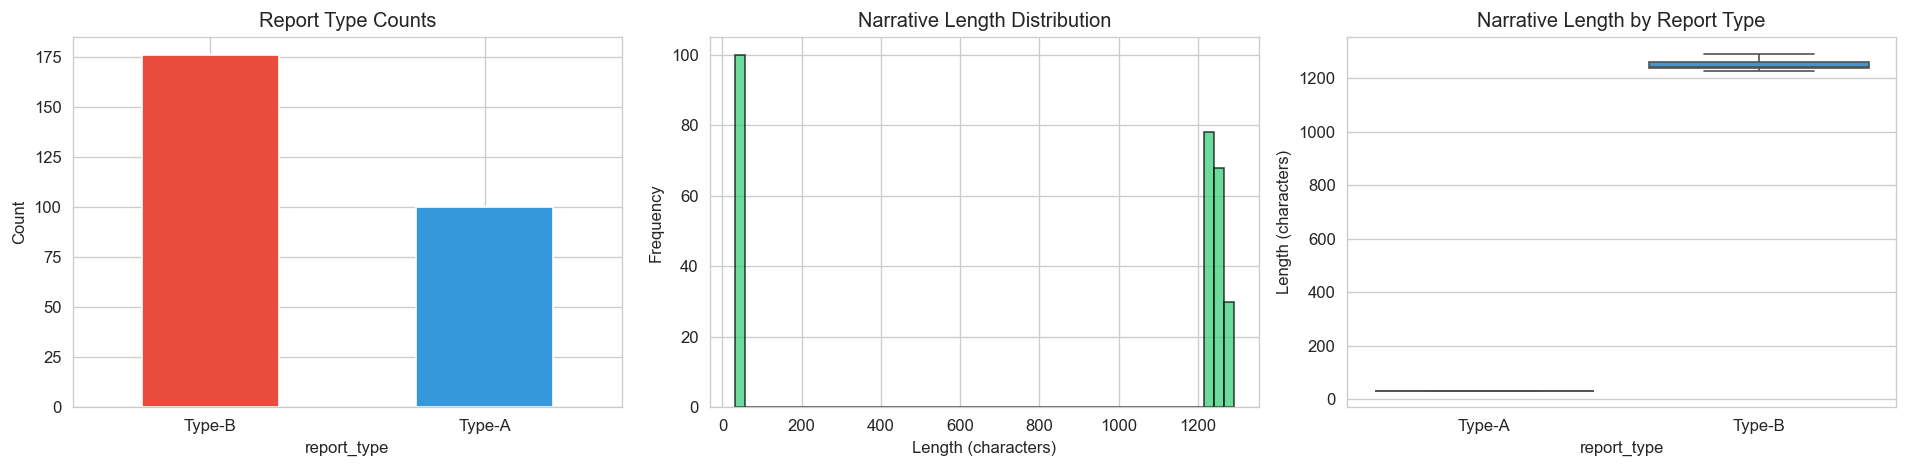


Narrative Length Stats by Report Type:

             count         mean        std     min     25%     50%     75%  \
report_type                                                                  
Type-A       100.0    32.000000   0.000000    32.0    32.0    32.0    32.0   
Type-B       176.0  1247.789773  15.667112  1227.0  1237.0  1242.0  1262.0   

                max  
report_type          
Type-A         32.0  
Type-B       1291.0  


In [6]:
print("Report Type Distribution:")
print(df['report_type'].value_counts())
print(f"\nPercentage Type-A: {df['report_type'].value_counts(normalize=True)['Type-A']*100:.1f}%")
print(f"Percentage Type-B: {df['report_type'].value_counts(normalize=True)['Type-B']*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['report_type'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'])
axes[0].set_title('Report Type Counts')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

axes[1].hist(df['narrative_length'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1].set_title('Narrative Length Distribution')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')

stats = df.groupby('report_type')['narrative_length'].describe()
sns.boxplot(data=df, x='report_type', y='narrative_length', ax=axes[2], palette={'Type-A': '#e74c3c', 'Type-B': '#3498db'})
axes[2].set_title('Narrative Length by Report Type')
axes[2].set_ylabel('Length (characters)')
plt.tight_layout()
plt.show()
print("\nNarrative Length Stats by Report Type:\n")
print(stats)

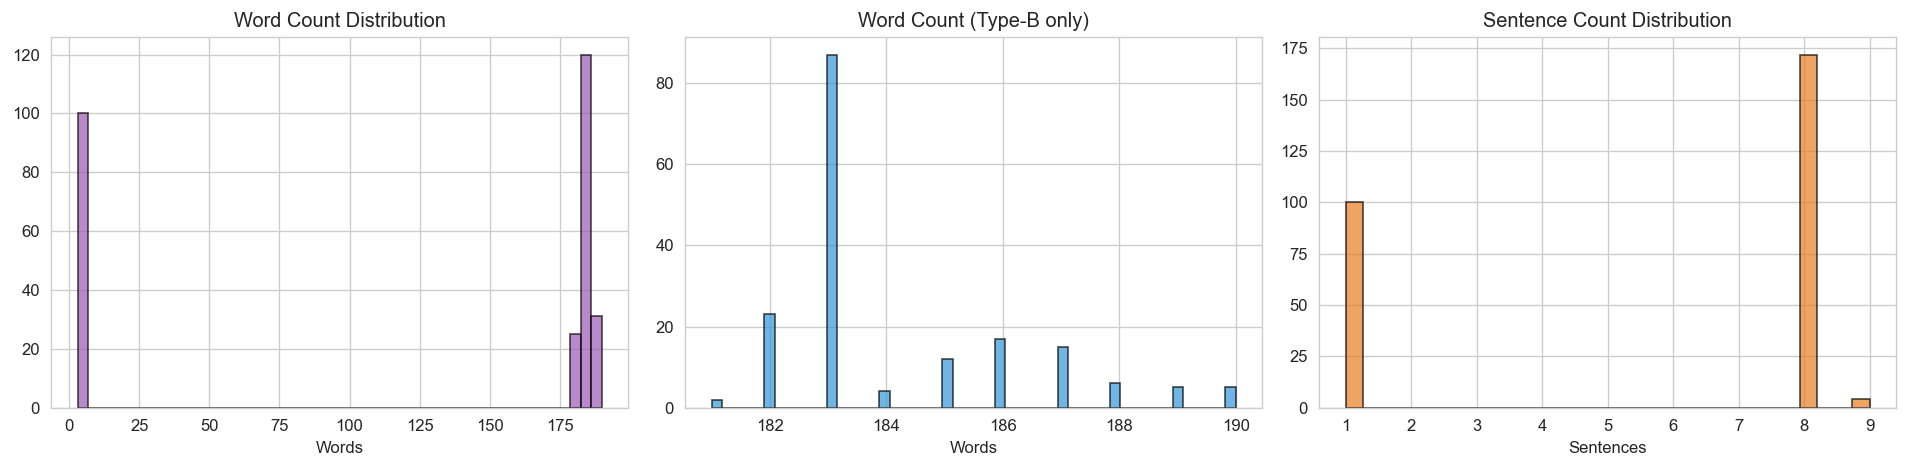

Text Statistics Summary:
       narrative_length  word_count  sentence_count  avg_word_length
count            276.00      276.00          276.00           276.00
mean             807.29      118.53            5.48             7.31
std              585.59       87.26            3.38             2.03
min               32.00        3.00            1.00             5.71
25%               32.00        3.00            1.00             5.77
50%             1236.00      183.00            8.00             5.80
75%             1245.00      183.00            8.00            10.00
max             1291.00      190.00            9.00            10.00


In [ ]:

df['word_count'] = df['narrative'].str.split().str.len()
df['sentence_count'] = df['narrative'].str.count(r'[.!?]')
df['avg_word_length'] = df['narrative'].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='#9b59b6')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df[df['report_type'] == 'Type-B']['word_count'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].set_title('Word Count (Type-B only)')
axes[1].set_xlabel('Words')

axes[2].hist(df['sentence_count'], bins=30, edgecolor='black', alpha=0.7, color='#e67e22')
axes[2].set_title('Sentence Count Distribution')
axes[2].set_xlabel('Sentences')
plt.tight_layout()
plt.show()

print("Text Statistics Summary:")
print(df[['narrative_length', 'word_count', 'sentence_count', 'avg_word_length']].describe().round(2))

## 3. Narrative Content Analysis (Key for Summarisation)

Understanding the vocabulary, common phrases, and structure of narratives.

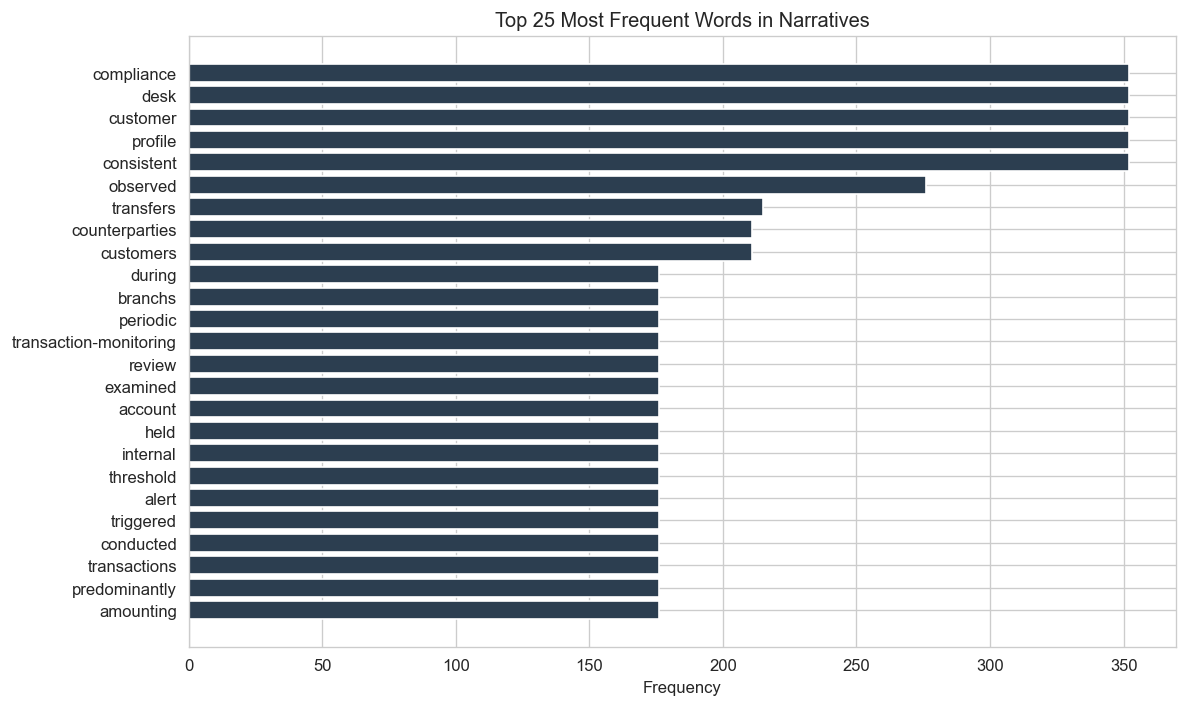


Top 15 Most Common Bigrams (meaningful pairs):
                         Bigram  Frequency
                  uring branchs        176
               branchs periodic        176
periodic transaction-monitoring        176
  transaction-monitoring review        176
              review compliance        176
                compliance desk        176
                  desk examined        176
               examined account        176
                   account held        176
             internal threshold        176
                threshold alert        176
                alert triggered        176
               triggered etween        176
             customer conducted        176
         conducted transactions        176


In [ ]:

STOPWORDS = set([
    'the', 'a', 'an', 'of', 'in', 'to', 'and', 'for', 'is', 'was', 'on', 'at',
    'by', 'with', 'from', 'as', 'are', 'were', 'be', 'been', 'being', 'has',
    'have', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should',
    'may', 'might', 'shall', 'can', 'not', 'no', 'nor', 'this', 'that', 'it',
    'its', 'they', 'them', 'their', 'we', 'our', 'you', 'your', 'he', 'she',
    'his', 'her', 'its', 'or', 'but', 'if', 'so', 'than', 'very', 'just',
    'about', 'above', 'after', 'all', 'also', 'an', 'any', 'because', 'been',
    'before', 'being', 'between', 'both', 'each', 'few', 'more', 'most',
    'other', 'some', 'such', 'only', 'own', 'same', 'too', 'up', 'down',
    'into', 'over', 'under', 'out', 'off', 'then', 'once', 'here', 'there',
    'when', 'where', 'why', 'how', 'which', 'who', 'whom', 'what'
])

def get_word_freq(text_series, n=20):
    words = []
    for text in text_series.dropna():
        for w in str(text).lower().split():
            w_clean = re.sub(r'[^a-z0-9\-]', '', w)
            if w_clean and w_clean not in STOPWORDS and len(w_clean) > 2:
                words.append(w_clean)
    return Counter(words).most_common(n)

common_words = get_word_freq(df['narrative'], 25)
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(words_df)), words_df['Frequency'][::-1], color='#2c3e50')
ax.set_yticks(range(len(words_df)))
ax.set_yticklabels(words_df['Word'][::-1])
ax.set_xlabel('Frequency')
ax.set_title('Top 25 Most Frequent Words in Narratives')
plt.tight_layout()
plt.show()

# Common phrases (bigrams)
def get_bigrams(text_series, n=15):
    bigrams = []
    for text in text_series.dropna():
        words = [re.sub(r'[^a-z0-9\-]', '', w).lower() for w in str(text).split()]
        words = [w for w in words if w and w not in STOPWORDS and len(w) > 2]
        for i in range(len(words) - 1):
            bigrams.append(f"{words[i]} {words[i+1]}")
    return Counter(bigrams).most_common(n)

common_bigrams = get_bigrams(df['narrative'], 15)
bigram_df = pd.DataFrame(common_bigrams, columns=['Bigram', 'Frequency'])
print("\nTop 15 Most Common Bigrams (meaningful pairs):")
print(bigram_df.to_string(index=False))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20740\122959637.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='report_type', y='entity_types_present', ax=axes[1],


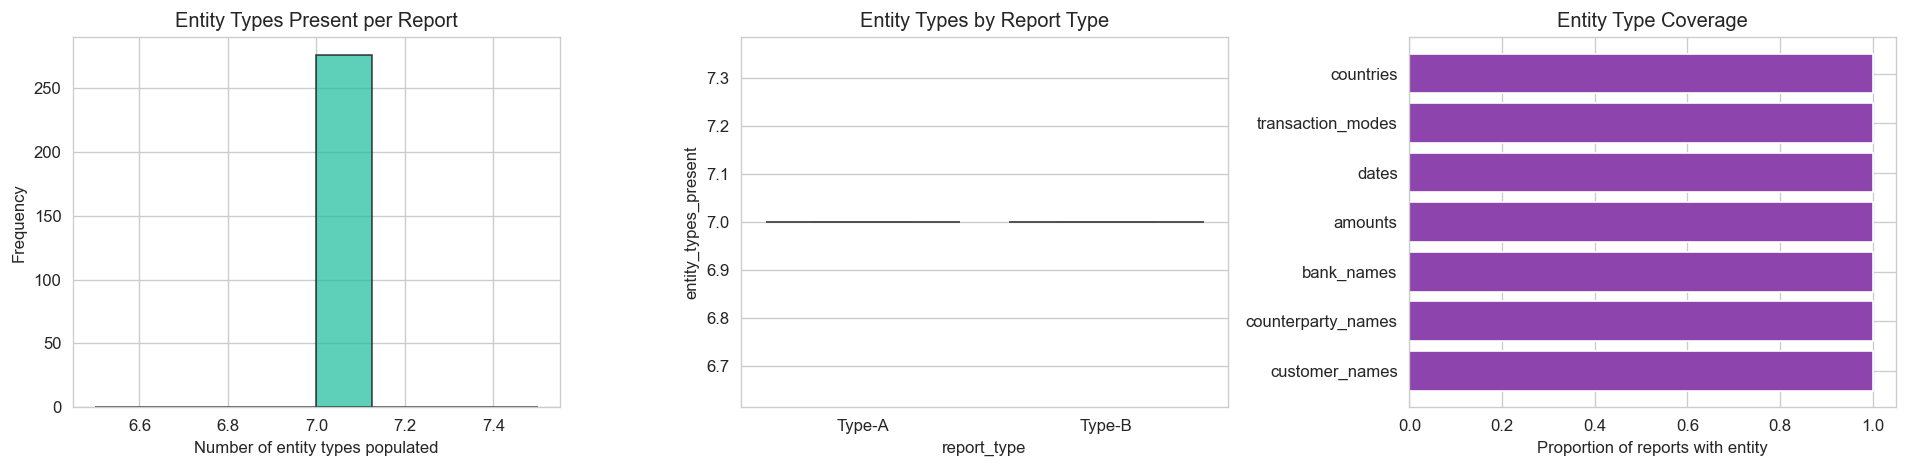


Entity Type Coverage (proportion of reports with each type populated):
entities_customer_names_present        1.0
entities_counterparty_names_present    1.0
entities_bank_names_present            1.0
entities_amounts_present               1.0
entities_dates_present                 1.0
entities_transaction_modes_present     1.0
entities_countries_present             1.0
dtype: float64


In [ ]:

df['entity_count'] = df['entities_json'].apply(
    lambda x: len(eval(x)) if pd.notna(x) else 0
)

entity_cols = ['entities_customer_names', 'entities_counterparty_names',
               'entities_bank_names', 'entities_amounts', 'entities_dates',
               'entities_transaction_modes', 'entities_countries']

for col in entity_cols:
    df[f'{col}_present'] = df[col].notna().astype(int)

df['entity_types_present'] = df[[f'{c}_present' for c in entity_cols]].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['entity_types_present'], bins=8, edgecolor='black', alpha=0.7, color='#1abc9c')
axes[0].set_title('Entity Types Present per Report')
axes[0].set_xlabel('Number of entity types populated')
axes[0].set_ylabel('Frequency')

sns.boxplot(data=df, x='report_type', y='entity_types_present', ax=axes[1],
            palette={'Type-A': '#e74c3c', 'Type-B': '#3498db'})
axes[1].set_title('Entity Types by Report Type')

entity_coverage = df[[f'{c}_present' for c in entity_cols]].mean().sort_values()
axes[2].barh(range(len(entity_coverage)), entity_coverage.values, color='#8e44ad')
axes[2].set_yticks(range(len(entity_coverage)))
axes[2].set_yticklabels([c.replace('entities_', '').replace('_present', '') for c in entity_coverage.index])
axes[2].set_xlabel('Proportion of reports with entity')
axes[2].set_title('Entity Type Coverage')
plt.tight_layout()
plt.show()

print("\nEntity Type Coverage (proportion of reports with each type populated):")
print(entity_coverage.round(3))

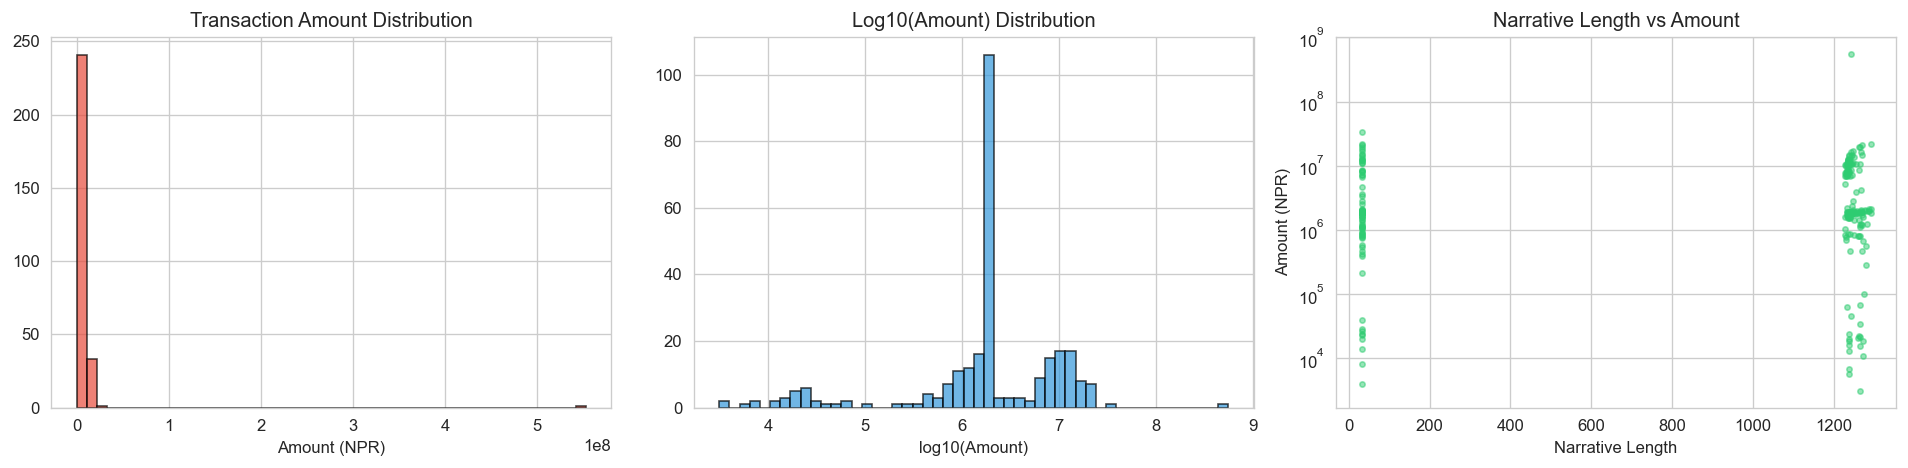

Amount Statistics (NPR):
count            276.00
mean       6,303,824.72
std       33,445,151.39
min            3,115.42
25%        1,421,497.54
50%        1,855,444.22
75%        7,037,073.60
max      552,796,380.22
Name: parsed_amount, dtype: object


In [ ]:

def parse_amount(amt_str):
    try:
        if pd.notna(amt_str):
            return float(re.sub(r'[^0-9.]', '', str(amt_str).split()[-1]))
    except:
        pass
    return np.nan

df['parsed_amount'] = df['entities_amounts'].apply(parse_amount)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['parsed_amount'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (NPR)')

axes[1].hist(np.log10(df['parsed_amount'].dropna() + 1), bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].set_title('Log10(Amount) Distribution')
axes[1].set_xlabel('log10(Amount)')

axes[2].scatter(df['narrative_length'], df['parsed_amount'], alpha=0.5, s=10, c='#2ecc71')
axes[2].set_title('Narrative Length vs Amount')
axes[2].set_xlabel('Narrative Length')
axes[2].set_ylabel('Amount (NPR)')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

print("Amount Statistics (NPR):")
print(df['parsed_amount'].describe().apply(lambda x: f'{x:,.2f}'))

## 4. Geographic & Institutional Analysis

Understanding the geographic spread and institutional patterns in reports.

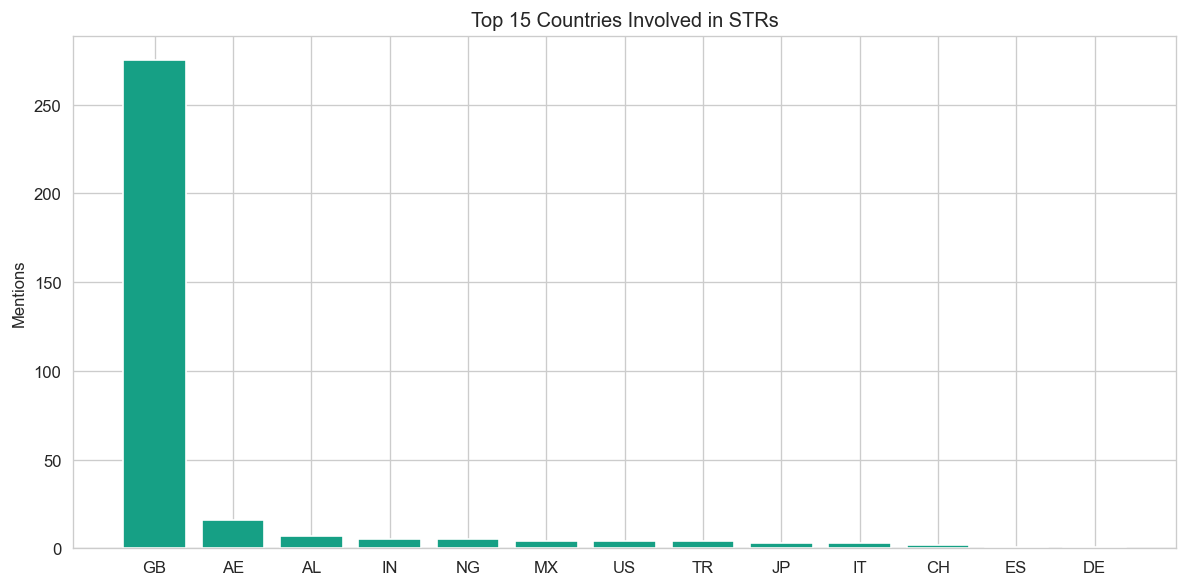

Cross-border reports: 54 (19.6%)
Domestic-only reports: 222 (80.4%)


In [ ]:

all_countries = []
for countries in df['entities_countries'].dropna():
    all_countries.extend([c.strip() for c in str(countries).split(';')])

country_counts = Counter(all_countries)
country_df = pd.DataFrame(country_counts.most_common(15), columns=['Country', 'Count'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(country_df)), country_df['Count'], color='#16a085')
ax.set_xticks(range(len(country_df)))
ax.set_xticklabels(country_df['Country'])
ax.set_title('Top 15 Countries Involved in STRs')
ax.set_ylabel('Mentions')
plt.tight_layout()
plt.show()


df['is_cross_border'] = df['entities_countries'].str.contains(';', na=False).astype(int)
print(f"Cross-border reports: {df['is_cross_border'].sum()} ({df['is_cross_border'].mean()*100:.1f}%)")
print(f"Domestic-only reports: {(1 - df['is_cross_border']).sum()} ({(1 - df['is_cross_border']).mean()*100:.1f}%)")

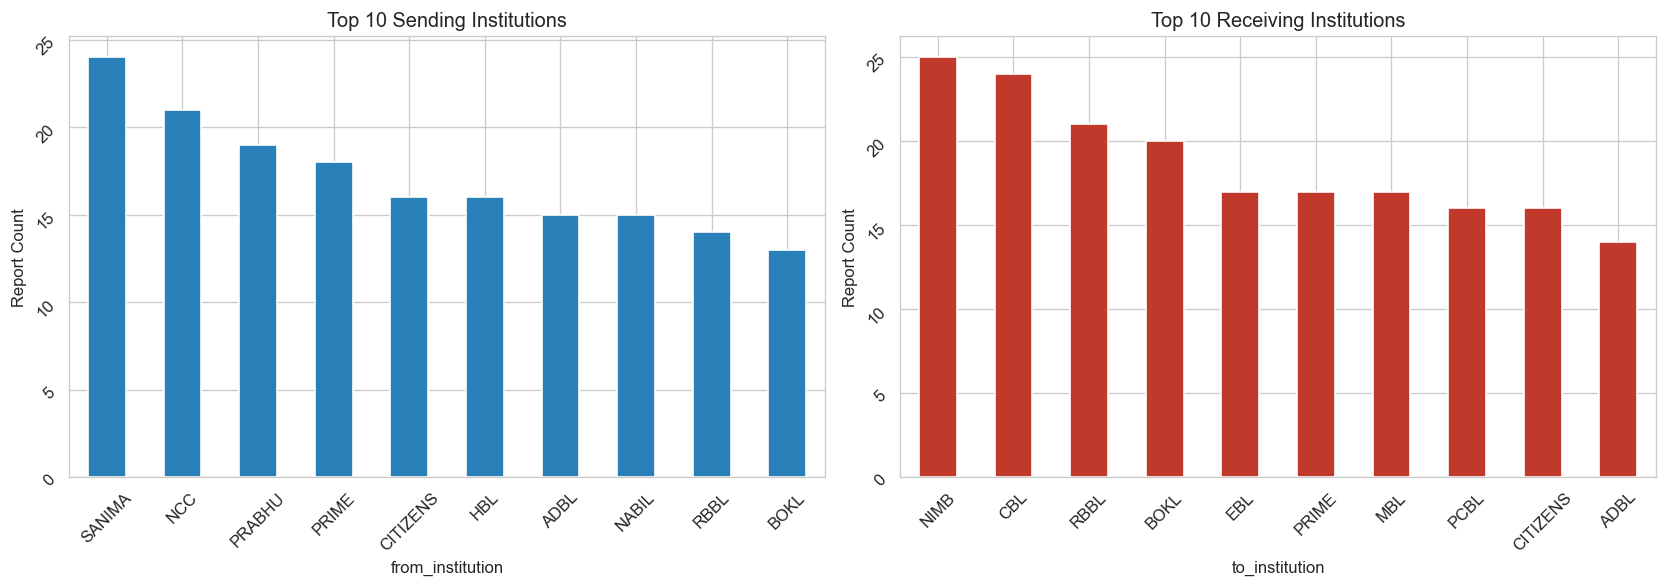

In [ ]:

from_institutions = df['from_institution'].value_counts().head(10)
to_institutions = df['to_institution'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
from_institutions.plot(kind='bar', ax=axes[0], color='#2980b9')
axes[0].set_title('Top 10 Sending Institutions')
axes[0].set_ylabel('Report Count')
axes[0].tick_params(rotation=45)

to_institutions.plot(kind='bar', ax=axes[1], color='#c0392b')
axes[1].set_title('Top 10 Receiving Institutions')
axes[1].set_ylabel('Report Count')
axes[1].tick_params(rotation=45)
plt.tight_layout()
plt.show()

## 5. Transaction Mode Distribution

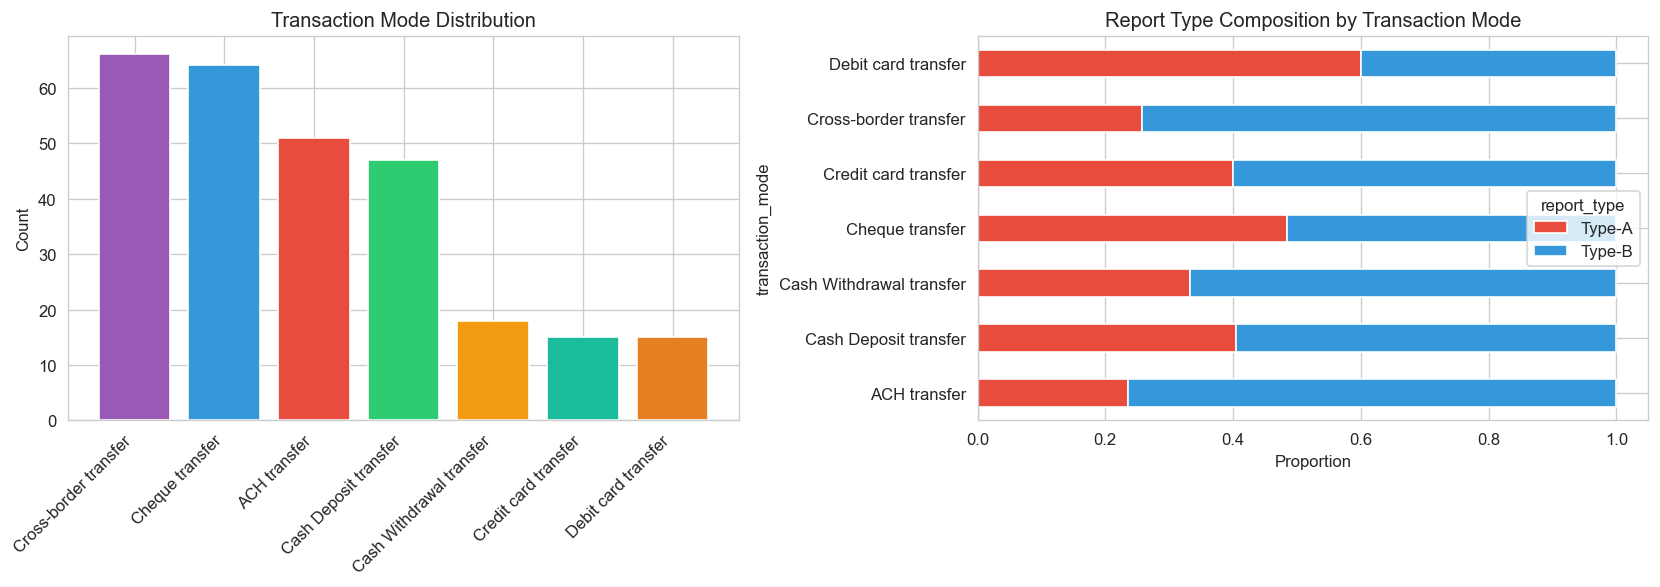

transaction_mode
Cross-border transfer       66
Cheque transfer             64
ACH transfer                51
Cash Deposit transfer       47
Cash Withdrawal transfer    18
Credit card transfer        15
Debit card transfer         15


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mode_counts = df['transaction_mode'].value_counts()
axes[0].bar(range(len(mode_counts)), mode_counts.values, color=['#9b59b6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#1abc9c', '#e67e22'])
axes[0].set_xticks(range(len(mode_counts)))
axes[0].set_xticklabels(mode_counts.index, rotation=45, ha='right')
axes[0].set_title('Transaction Mode Distribution')
axes[0].set_ylabel('Count')


ct = pd.crosstab(df['transaction_mode'], df['report_type'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.plot(kind='barh', stacked=True, ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_title('Report Type Composition by Transaction Mode')
axes[1].set_xlabel('Proportion')
plt.tight_layout()
plt.show()
print(mode_counts.to_string())

## 6. Summarisation Challenge Analysis

Understanding what makes narratives easy or hard to summarise.

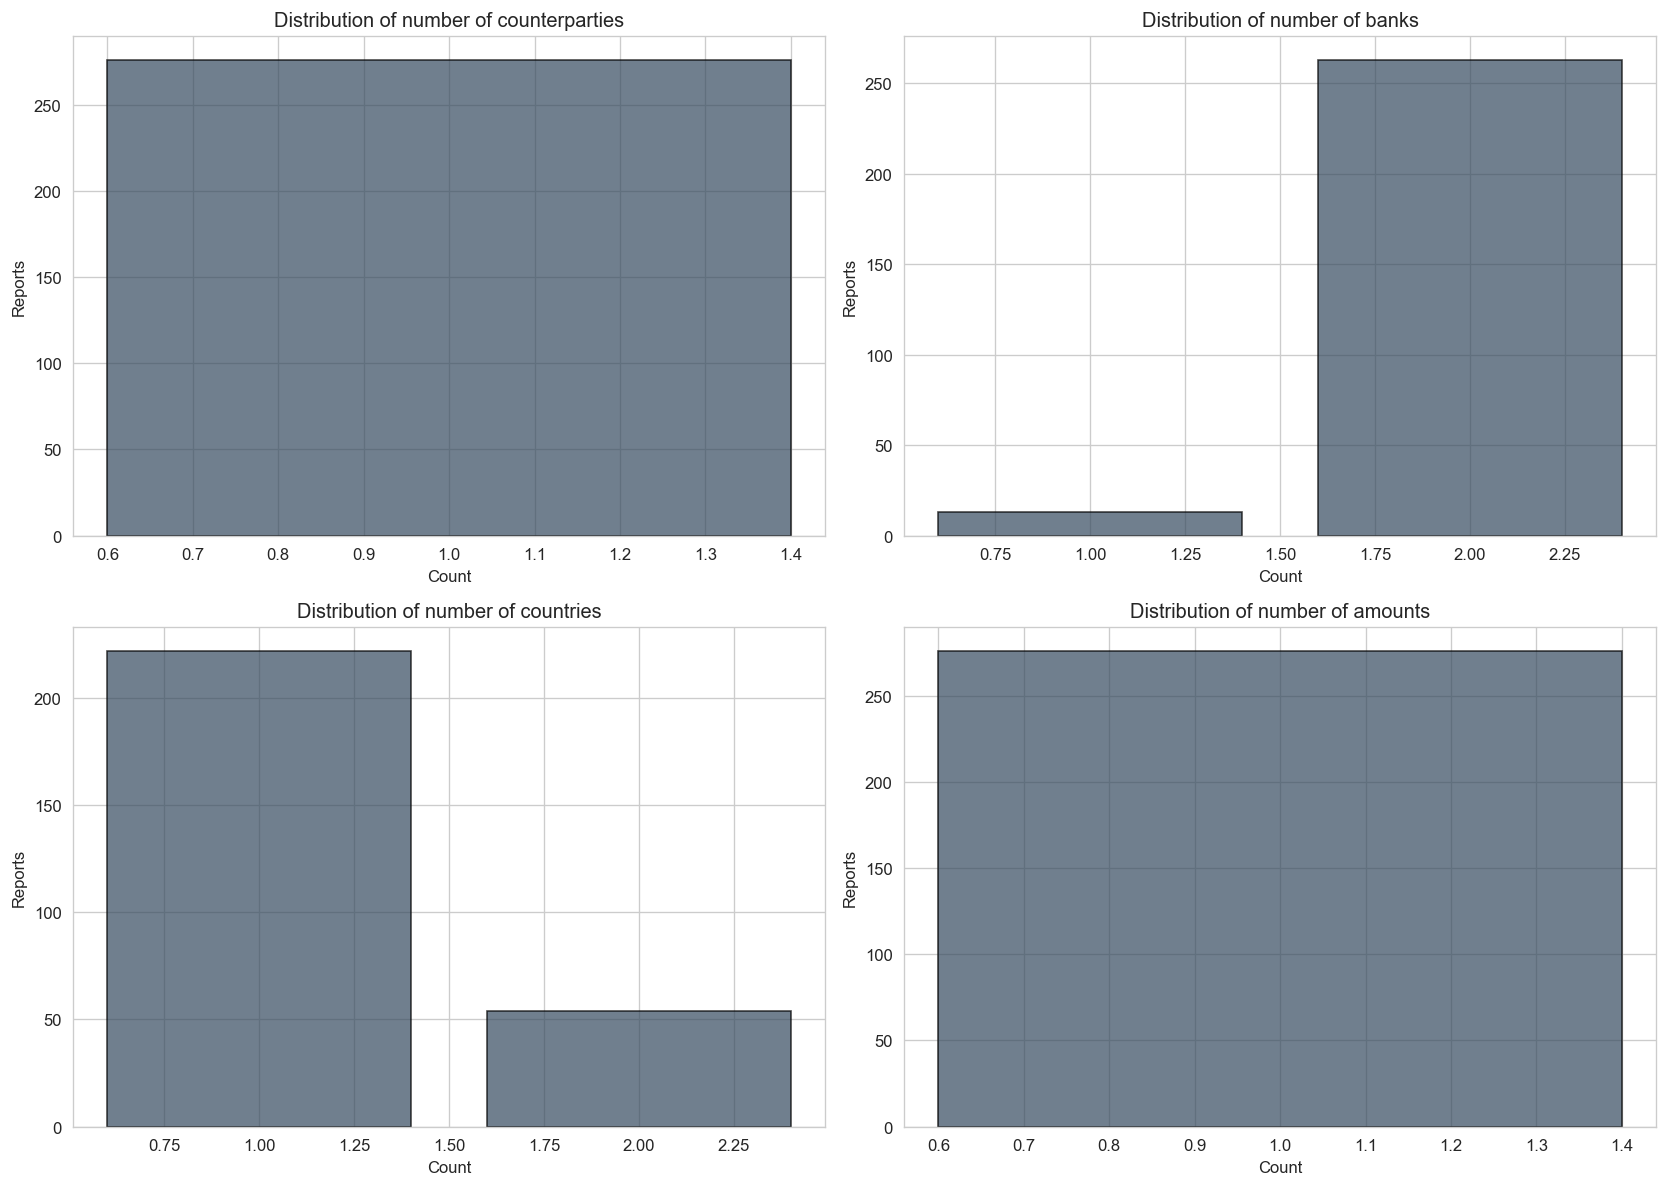


Entity Multiplicity Summary:
       n_counterparties  n_banks  n_countries  n_amounts
count               276      276          276        276
mean                  1        1            1          1
std                   0        0            0          0
min                   1        1            1          1
25%                   1        2            1          1
50%                   1        2            1          1
75%                   1        2            1          1
max                   1        2            2          1


In [ ]:

def count_entities_in_col(col_series):
    """Count how many distinct entities appear in a semicolon-separated field."""
    def _count(val):
        if pd.isna(val) or str(val).strip() == '':
            return 0
        return len([x for x in str(val).split(';') if x.strip()])
    return col_series.apply(_count)

df['n_counterparties'] = count_entities_in_col(df['entities_counterparty_names'])
df['n_banks'] = count_entities_in_col(df['entities_bank_names'])
df['n_countries'] = count_entities_in_col(df['entities_countries'])
df['n_amounts'] = count_entities_in_col(df['entities_amounts'])

multiplicity_cols = ['n_counterparties', 'n_banks', 'n_countries', 'n_amounts']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), multiplicity_cols):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, edgecolor='black', alpha=0.7, color='#34495e')
    ax.set_title(f'Distribution of {col.replace("n_", "number of ")}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Reports')
plt.tight_layout()
plt.show()

print("\nEntity Multiplicity Summary:")
print(df[multiplicity_cols].describe().astype(int))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20740\3296159247.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='report_type', y='total_entity_mentions', ax=axes[1],


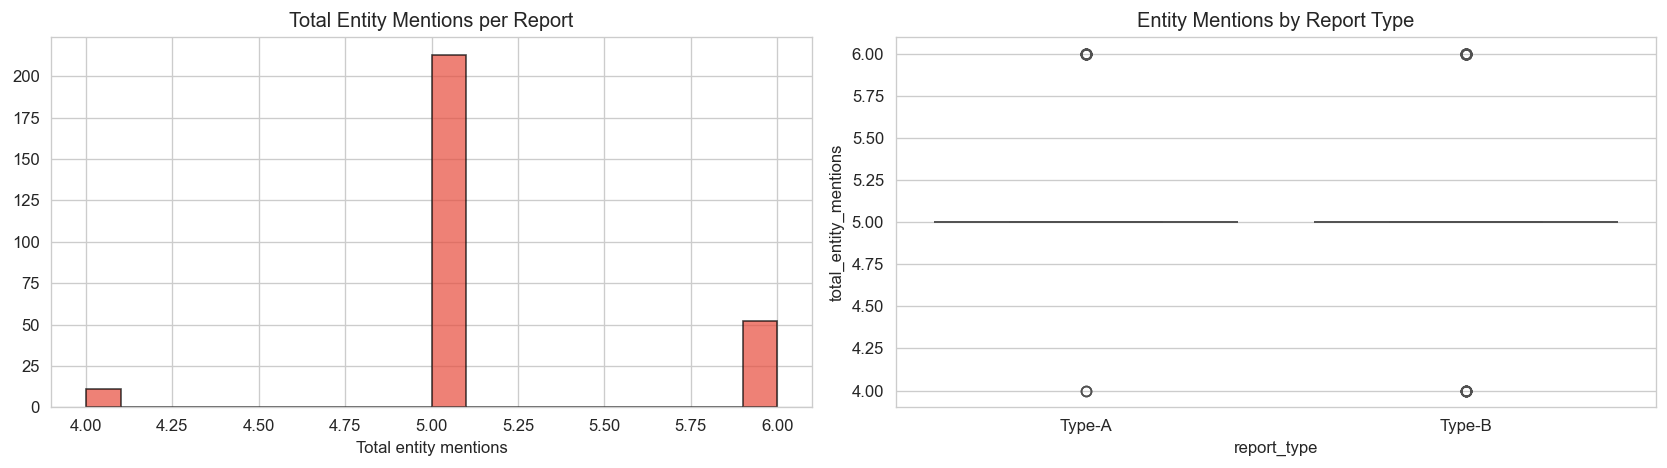


Entity Mentions Summary:
             count  mean   std  min  25%  50%  75%  max
report_type                                            
Type-A       100.0  5.17  0.43  4.0  5.0  5.0  5.0  6.0
Type-B       176.0  5.14  0.47  4.0  5.0  5.0  5.0  6.0


In [ ]:

df['total_entity_mentions'] = df[multiplicity_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['total_entity_mentions'], bins=20, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[0].set_title('Total Entity Mentions per Report')
axes[0].set_xlabel('Total entity mentions')

sns.boxplot(data=df, x='report_type', y='total_entity_mentions', ax=axes[1],
            palette={'Type-A': '#e74c3c', 'Type-B': '#3498db'})
axes[1].set_title('Entity Mentions by Report Type')
plt.tight_layout()
plt.show()

print("\nEntity Mentions Summary:")
print(df.groupby('report_type')['total_entity_mentions'].describe().round(2))

## 7. Statistical Summary & Correlations

In [16]:
print("Statistical Summary of Numeric Columns:")
print("="*50)
numeric_cols = ['narrative_length', 'amount_local', 'word_count', 'sentence_count',
                'entity_types_present', 'total_entity_mentions']
print(df[numeric_cols].describe().round(2))

Statistical Summary of Numeric Columns:
       narrative_length  amount_local  word_count  sentence_count  \
count            276.00  2.760000e+02      276.00          276.00   
mean             807.29  6.303825e+06      118.53            5.48   
std              585.59  3.344515e+07       87.26            3.38   
min               32.00  3.115420e+03        3.00            1.00   
25%               32.00  1.421498e+06        3.00            1.00   
50%             1236.00  1.855444e+06      183.00            8.00   
75%             1245.00  7.037074e+06      183.00            8.00   
max             1291.00  5.527964e+08      190.00            9.00   

       entity_types_present  total_entity_mentions  
count                 276.0                 276.00  
mean                    7.0                   5.15  
std                     0.0                   0.45  
min                     7.0                   4.00  
25%                     7.0                   5.00  
50%                 

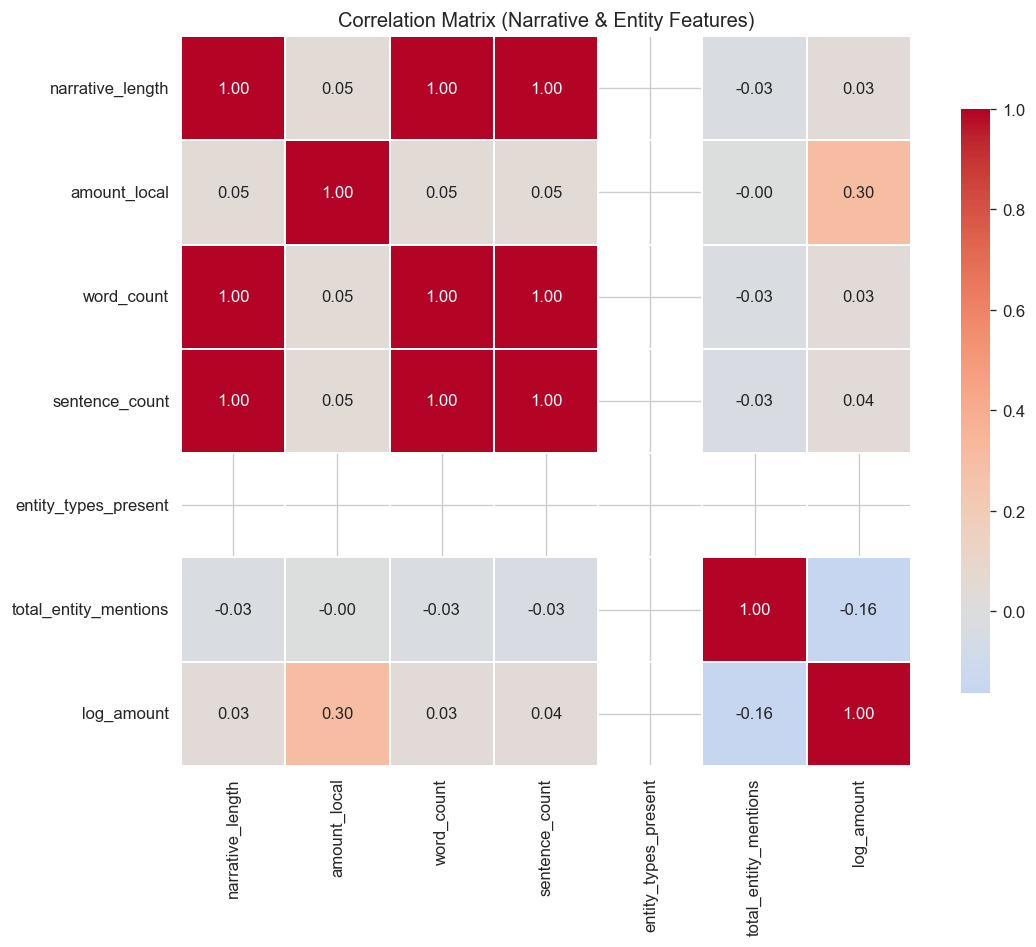


Key Correlations with Narrative Length:
narrative_length         1.000000
word_count               0.999972
sentence_count           0.999111
amount_local             0.048182
log_amount               0.032597
total_entity_mentions   -0.025263
entity_types_present          NaN


In [ ]:

corr_cols = ['narrative_length', 'amount_local', 'word_count', 'sentence_count',
             'entity_types_present', 'total_entity_mentions']
corr_data = df[corr_cols].copy()

corr_data['log_amount'] = np.log10(df['parsed_amount'].fillna(1) + 1)

plt.figure(figsize=(10, 8))
correlation = corr_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Narrative & Entity Features)')
plt.tight_layout()
plt.show()

print("\nKey Correlations with Narrative Length:")
with pd.option_context('display.max_rows', None):
    print(correlation['narrative_length'].sort_values(ascending=False).to_string())